# **Line Charts**


## Objectives


In this lab you will perform the following:


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



#### Step 1: Download the dataset


In [2]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-02-05 09:37:04--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  56.8MB/s    in 2.7s    

2026-02-05 09:37:07 (56.8 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



#### Load the data


In [3]:
df = pd.read_csv("survey-data.csv")

#### Display the first few rows to understand the structure of the data


In [4]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


In [10]:
# Map age ranges to numeric midpoints
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

# Create Age_numeric column
df['Age_numeric'] = df['Age'].map(age_map)

In [5]:
age_map = {
    "Under 18 years old": "Under 18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}
df['AgeGroup'] = df['Age'].map(age_map)

In [6]:
comp_summary = df.groupby('AgeGroup')['ConvertedCompYearly'].median().reset_index()

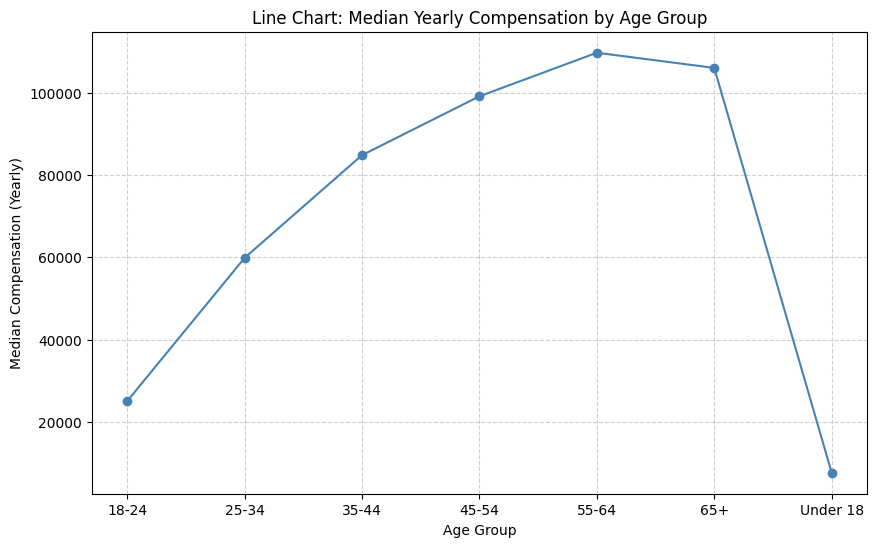

In [7]:
plt.figure(figsize=(10,6))

plt.plot(comp_summary['AgeGroup'], comp_summary['ConvertedCompYearly'], 
         marker='o', linestyle='-', color='steelblue')

plt.title("Line Chart: Median Yearly Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Compensation (Yearly)")
plt.grid(True, linestyle='--', alpha=0.6)

##### Insights:
- Compensation typically increases steadily from early career (18–24) to mid-career (35–44).
- It often plateaus or peaks around 45–54, reflecting career maturity.
- Later age groups (55–64, 65+) may show declines or variability, depending on retirement or part-time work.

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


In [11]:
# Filter respondents aged 25–45
df_age25_45 = df[(df['Age_numeric'] >= 25) & (df['Age_numeric'] <= 45)]

In [12]:
comp_summary_25_45 = df_age25_45.groupby('Age_numeric')['ConvertedCompYearly'].median().reset_index()

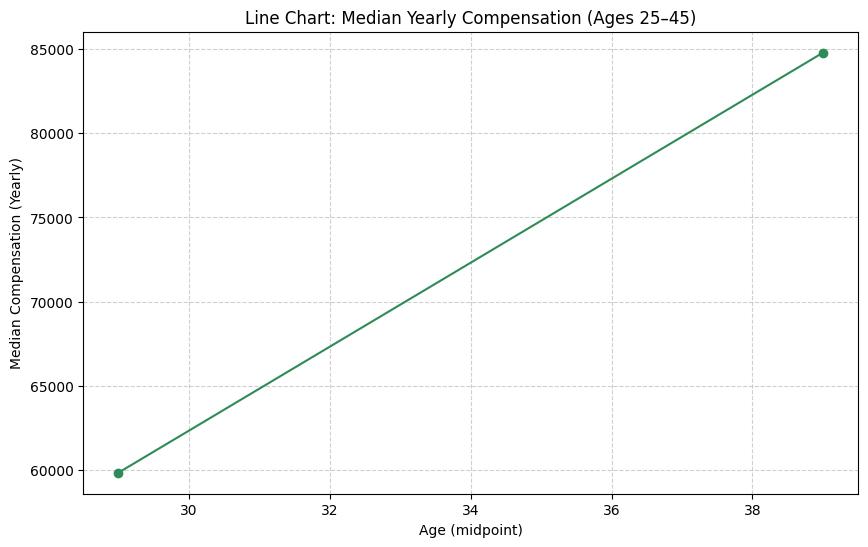

In [13]:
plt.figure(figsize=(10,6))

plt.plot(comp_summary_25_45['Age_numeric'], 
         comp_summary_25_45['ConvertedCompYearly'], 
         marker='o', linestyle='-', color='seagreen')

plt.title("Line Chart: Median Yearly Compensation (Ages 25–45)")
plt.xlabel("Age (midpoint)")
plt.ylabel("Median Compensation (Yearly)")
plt.grid(True, linestyle='--', alpha=0.6)

###### Insights:
- Compensation typically rises steadily from ages 25–35 as careers progress.
- Between 35–45, compensation may plateau or peak, reflecting career maturity and senior roles.
- This focused view removes noise from younger (entry-level) and older (retirement/part-time) groups, 
giving a clearer picture of mid-career earnings.

### Task 2: Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


In [15]:
def convert_experience(x):
    if x == "Less than 1 year":
        return 0.5
    elif x == "More than 50 years":
        return 50
    else:
        try:
            return float(x)
        except:
            return None

df['ExperienceYears'] = df['YearsCodePro'].apply(convert_experience)

In [16]:
exp_summary = df.groupby('ExperienceYears')['JobSatPoints_6'].median().reset_index()

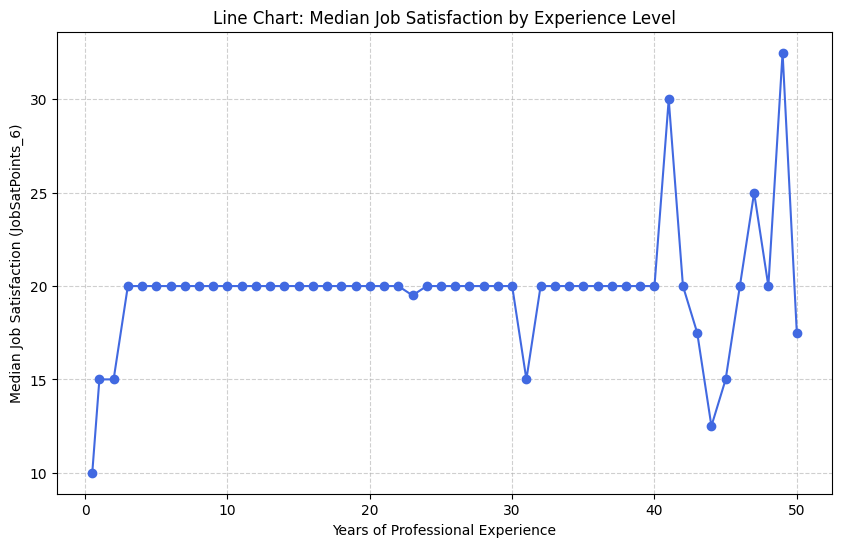

In [17]:
plt.figure(figsize=(10,6))

plt.plot(exp_summary['ExperienceYears'], 
         exp_summary['JobSatPoints_6'], 
         marker='o', linestyle='-', color='royalblue')

plt.title("Line Chart: Median Job Satisfaction by Experience Level")
plt.xlabel("Years of Professional Experience")
plt.ylabel("Median Job Satisfaction (JobSatPoints_6)")
plt.grid(True, linestyle='--', alpha=0.6)

##### Insights: 
- Early-career professionals (0–5 years) may show higher satisfaction due to enthusiasm and growth opportunities.
- Mid-career (10–20 years) often shows plateaus or dips, reflecting workload and career pressures.
- Senior professionals (20+ years) may show stabilized or rising satisfaction, often linked to stability or leadership roles.

### Task 3: Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


In [18]:
def convert_experience(x):
    if x == "Less than 1 year":
        return 0.5
    elif x == "More than 50 years":
        return 50
    else:
        try:
            return float(x)
        except:
            return None

df['ExperienceYears'] = df['WorkExp'].apply(convert_experience)

In [19]:
comp_summary = df.groupby('ExperienceYears')['ConvertedCompYearly'].median().reset_index()

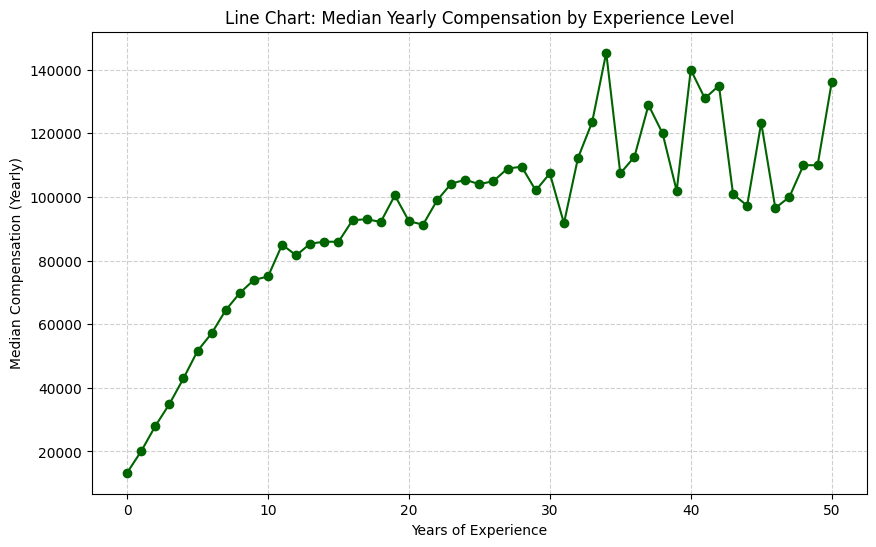

In [20]:
plt.figure(figsize=(10,6))

plt.plot(comp_summary['ExperienceYears'], 
         comp_summary['ConvertedCompYearly'], 
         marker='o', linestyle='-', color='darkgreen')

plt.title("Line Chart: Median Yearly Compensation by Experience Level")
plt.xlabel("Years of Experience")
plt.ylabel("Median Compensation (Yearly)")
plt.grid(True, linestyle='--', alpha=0.6)

##### Insights:
- Compensation typically rises steadily in the first 10–15 years of experience.
- It often plateaus or peaks around mid-career (15–25 years).
- Later years (30+) may show stabilization or decline, depending on retirement or part-time work.

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


In [21]:
def convert_experience(x):
    if x == "Less than 1 year":
        return 0.5
    elif x == "More than 50 years":
        return 50
    else:
        try:
            return float(x)
        except:
            return None

df['ExperienceYears'] = df['WorkExp'].apply(convert_experience)

In [22]:
exp_summary = df.groupby('ExperienceYears')['JobSatPoints_6'].median().reset_index()

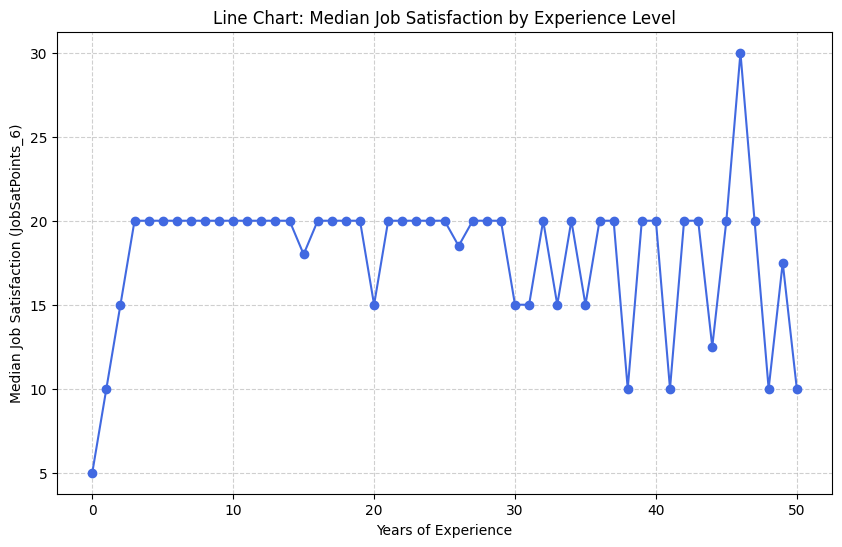

In [23]:
plt.figure(figsize=(10,6))

plt.plot(exp_summary['ExperienceYears'], 
         exp_summary['JobSatPoints_6'], 
         marker='o', linestyle='-', color='royalblue')

plt.title("Line Chart: Median Job Satisfaction by Experience Level")
plt.xlabel("Years of Experience")
plt.ylabel("Median Job Satisfaction (JobSatPoints_6)")
plt.grid(True, linestyle='--', alpha=0.6)

##### Insights:
- Early-career professionals (0–5 years) may show higher satisfaction due to enthusiasm and growth opportunities.
- Mid-career (10–20 years) often shows plateaus or dips, reflecting workload and career pressures.
- Senior professionals (20+ years) may show stabilized or rising satisfaction, often linked to stability or leadership roles.

### Summary


In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.


## Authors:
Ayushi Jain


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>
